<a href="https://colab.research.google.com/github/Amarmurun0212/Diver/blob/main/WindTurbine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

😃 Танилцуулга (Introduction)
Texas Wind Turbine Dataset-ийн тухай
Асуудлын тодорхойлолт (Problem Statement)

Салхины эрчим хүч нь байгаль цаг уурын нөхцөлөөс шууд хамаардаг тул тогтмол биш (intermittent) шинж чанартай байдаг. Иймээс цахилгаан эрчим хүчний сүлжээний операторууд эрчим хүчний эрэлт хэрэгцээг хангахын зэрэгцээ салхин болон нарны цахилгаан станцууд ирэх цаг, өдөр, долоо хоногт хэр хэмжээний эрчим хүч үйлдвэрлэхийг урьдчилан таамаглах шаардлагатай болдог.

Хэрэв салхин станцын үйлдвэрлэлийг буруу таамаглавал:

Илүү их нөөц эрчим хүч бэлдэх шаардлага үүснэ.
Үйлдвэрлэлийн зардал нэмэгдэнэ.
Нэмэлт зардал хэрэглэгчдэд шилжинэ.
Илүү үнэтэй бөгөөд байгаль орчинд сөрөг нөлөөтэй эрчим хүчний эх үүсвэрүүдийг ашиглах шаардлага гарна.

Бодит өгөгдөл дээр ажиллахад дуу чимээ (noise) болон дутуу мэдээлэл зэрэг хүндрэлүүд байдаг. Харин энэхүү өгөгдлийн багц нь эдгээр асуудлыг арилгаж, таамаглалын аргуудыг суралцахад илүү тохиромжтой байдлаар бэлтгэгдсэн.

Өгөгдлийн багцын дэлгэрэнгүй (Dataset Details)

Энэхүү өгөгдөл нь АНУ-ын Техас мужийн нэг байршилд байрлах салхин турбины бүтэн жилийн цаг тутмын (hourly) мэдээлэл юм.

Өгөгдлийг АНУ-ын National Renewable Energy Laboratory (NREL) байгууллагын симуляцийн программ ашиглан үүсгэсэн.

Онцлог шинжүүд:

Бүтэн жилийн мэдээлэлтэй
Алдагдсан мөр (missing data) байхгүй
Алдаа (noise) агуулаагүй
Машин сургалт болон таамаглалын загвар боловсруулахад тохиромжтой


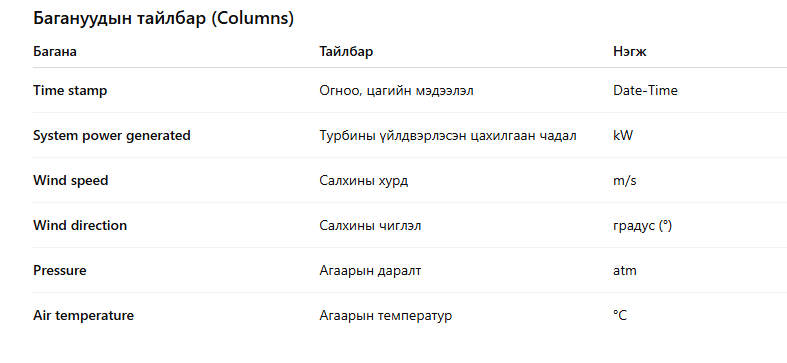

In [ ]:
#Importing the basic librarires fot analysis

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("Solarize_Light2")  #using style ggplot

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import datetime as dt
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt

#Importing the dataset
df =pd.read_csv("/content/TexasTurbine.csv")

# look the data set
df.head()

,Time stamp,System power generated | (kW),Wind speed | (m/s),Wind direction | (deg),Pressure | (atm),Air temperature | ('C)
0,2024-01-01 00:00:00,1766.64,9.926,128,1.000480,18.263
1,2024-01-01 01:00:00,1433.83,9.273,135,0.999790,18.363
2,2024-01-01 02:00:00,1167.23,8.660,142,0.999592,18.663
3,2024-01-01 03:00:00,1524.59,9.461,148,0.998309,18.763
4,2024-01-01 04:00:00,1384.28,9.184,150,0.998507,18.963


In [ ]:
# looking the shape DataSet
df.shape

(8760, 6)

In [ ]:
#Checking the dtypes of all the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Time stamp                     8760 non-null   object 
 1   System power generated | (kW)  8760 non-null   float64
 2   Wind speed | (m/s)             8760 non-null   float64
 3   Wind direction | (deg)         8760 non-null   int64  
 4   Pressure | (atm)               8760 non-null   float64
 5   Air temperature | ('C)         8760 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 410.8+ KB


In [ ]:
# 1. ISO форматыг datetime болгоно
df['Time stamp'] = pd.to_datetime(df['Time stamp'], format='mixed')

# 2. Өмнө хэрэглэдэг формат руу хөрвүүлж string болгоно
df['Time stamp'] = df['Time stamp'].dt.strftime('%b %d %H:%M:%S.%f')

# 3. Буцааж datetime хэлбэрт оруулна (хэрвээ танд үнэхээр энэ алхам хэрэгтэй бол)
df['Time stamp'] = df['Time stamp'].apply(
    lambda x: dt.datetime.strptime(x, '%b %d %H:%M:%S.%f')
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Time stamp                     8760 non-null   datetime64[ns]
 1   System power generated | (kW)  8760 non-null   float64       
 2   Wind speed | (m/s)             8760 non-null   float64       
 3   Wind direction | (deg)         8760 non-null   int64         
 4   Pressure | (atm)               8760 non-null   float64       
 5   Air temperature | ('C)         8760 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 410.8 KB


In [ ]:
# missing value

df.isnull().sum()

,0
Time stamp,0
System power generated | (kW),0
Wind speed | (m/s),0
Wind direction | (deg),0
Pressure | (atm),0
Air temperature | ('C),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Time stamp'] = pd.to_datetime(df['Time stamp'], format='mixed')
df['Time stamp'] = df['Time stamp'].apply(lambda x: x.replace(year=2024))

In [ ]:
# look  describe data set
df.describe().round(2)

,Time stamp,System power generated | (kW),Wind speed | (m/s),Wind direction | (deg),Pressure | (atm),Air temperature | ('C)
count,8760,8760.00,8760.00,8760.00,8760.00,8760.00
mean,2024-07-02 07:37:13.972602624,964.47,7.38,146.62,0.99,22.15
min,2024-01-01 00:00:00,0.00,0.12,0.00,0.97,3.26
25%,2024-04-02 05:45:00,215.95,5.12,99.00,0.99,19.46
50%,2024-07-02 11:30:00,693.97,7.34,135.00,0.99,22.76
75%,2024-10-01 17:15:00,1562.29,9.60,169.00,1.00,26.06
max,2024-12-31 23:00:00,3004.01,19.74,360.00,1.01,32.96
std,NaN,878.56,3.14,84.68,0.01,4.86


In [ ]:
# add column Month

df["Month"]=df["Time stamp"].dt.month

In [ ]:
df.head()

,Time stamp,System power generated | (kW),Wind speed | (m/s),Wind direction | (deg),Pressure | (atm),Air temperature | ('C),Month
0,2024-01-01 00:00:00,1766.64,9.926,128,1.000480,18.263,1
1,2024-01-01 01:00:00,1433.83,9.273,135,0.999790,18.363,1
2,2024-01-01 02:00:00,1167.23,8.660,142,0.999592,18.663,1
3,2024-01-01 03:00:00,1524.59,9.461,148,0.998309,18.763,1
4,2024-01-01 04:00:00,1384.28,9.184,150,0.998507,18.963,1


Visualizations

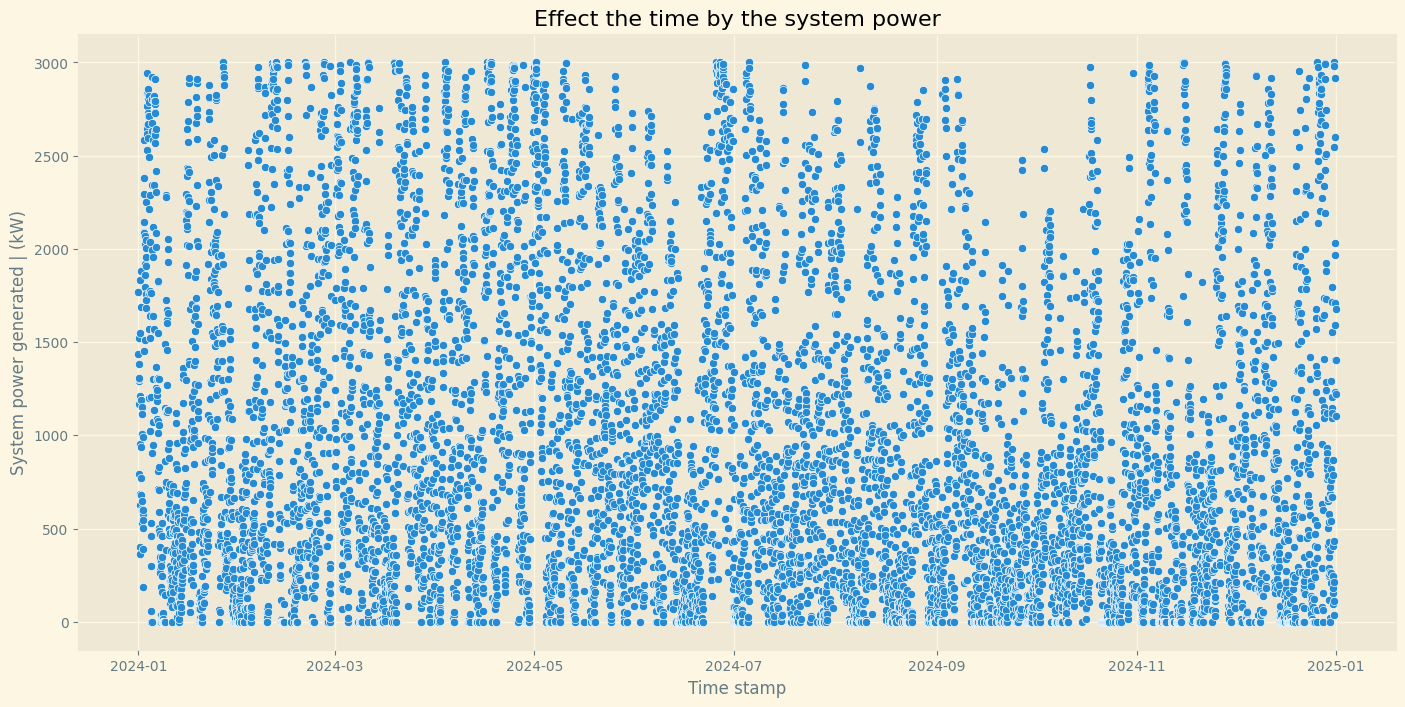

In [ ]:
# the graph show effect the time by the system power

plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="Time stamp",y="System power generated | (kW)",)
plt.title("Effect the time by the system power")
plt.show()

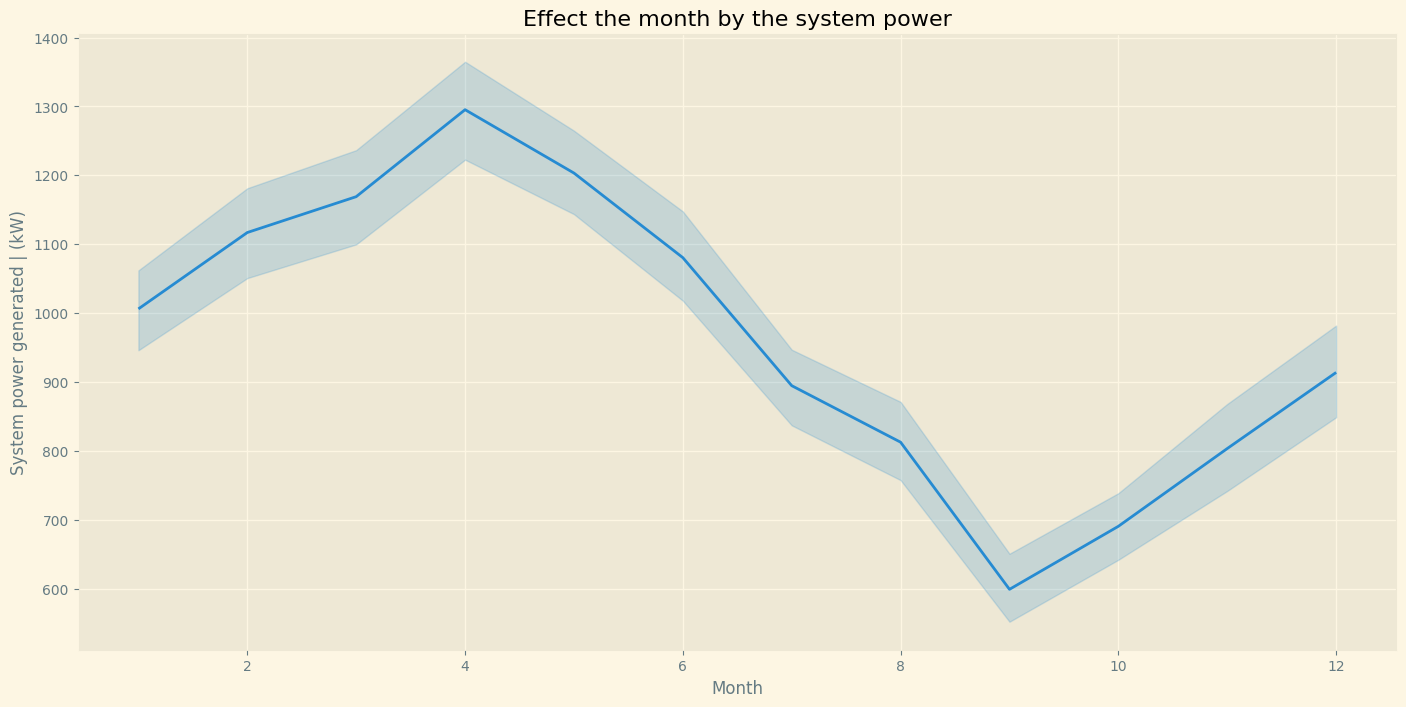

In [ ]:
# the graph show effect the month by the system power

plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="Month",y="System power generated | (kW)",)
plt.title("Effect the month by the system power")
plt.show()

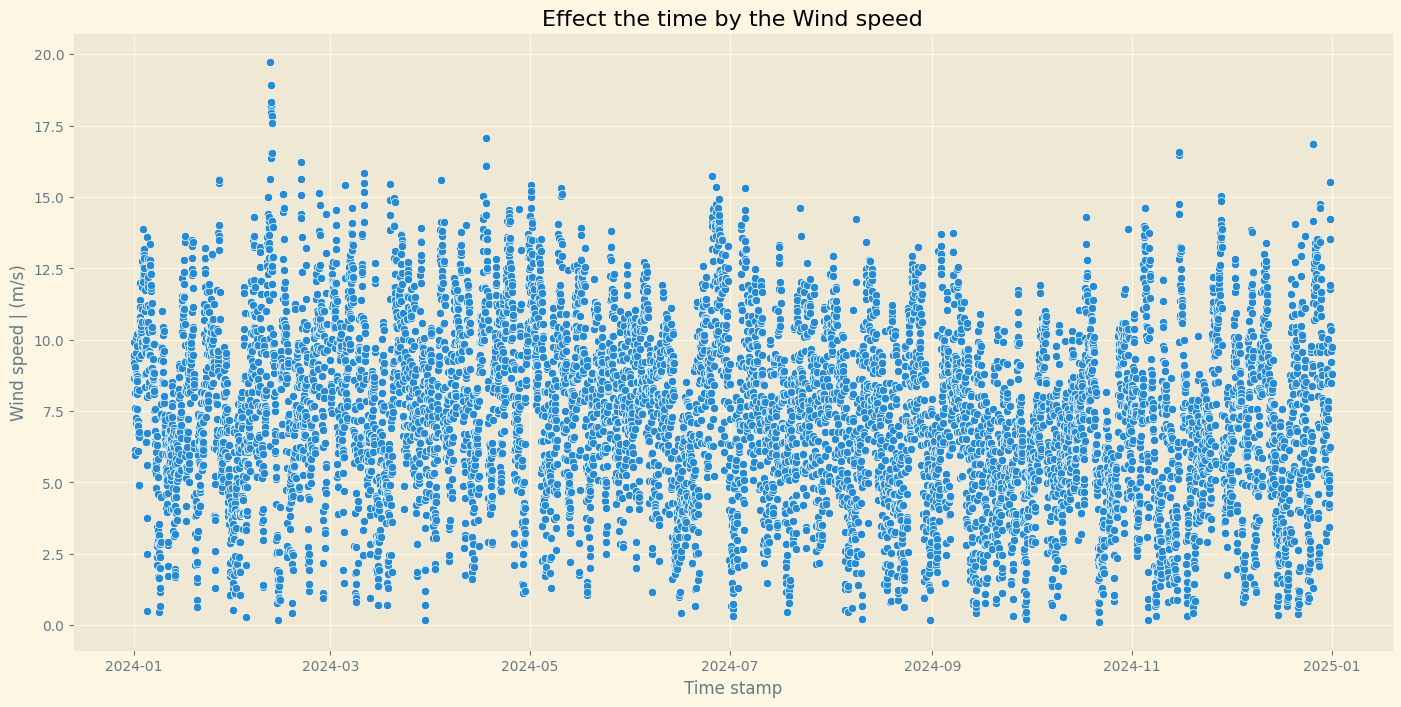

In [ ]:
# the graph show effect the time by the Wind speed

plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="Time stamp",y="Wind speed | (m/s)",)
plt.title("Effect the time by the Wind speed")
plt.show()

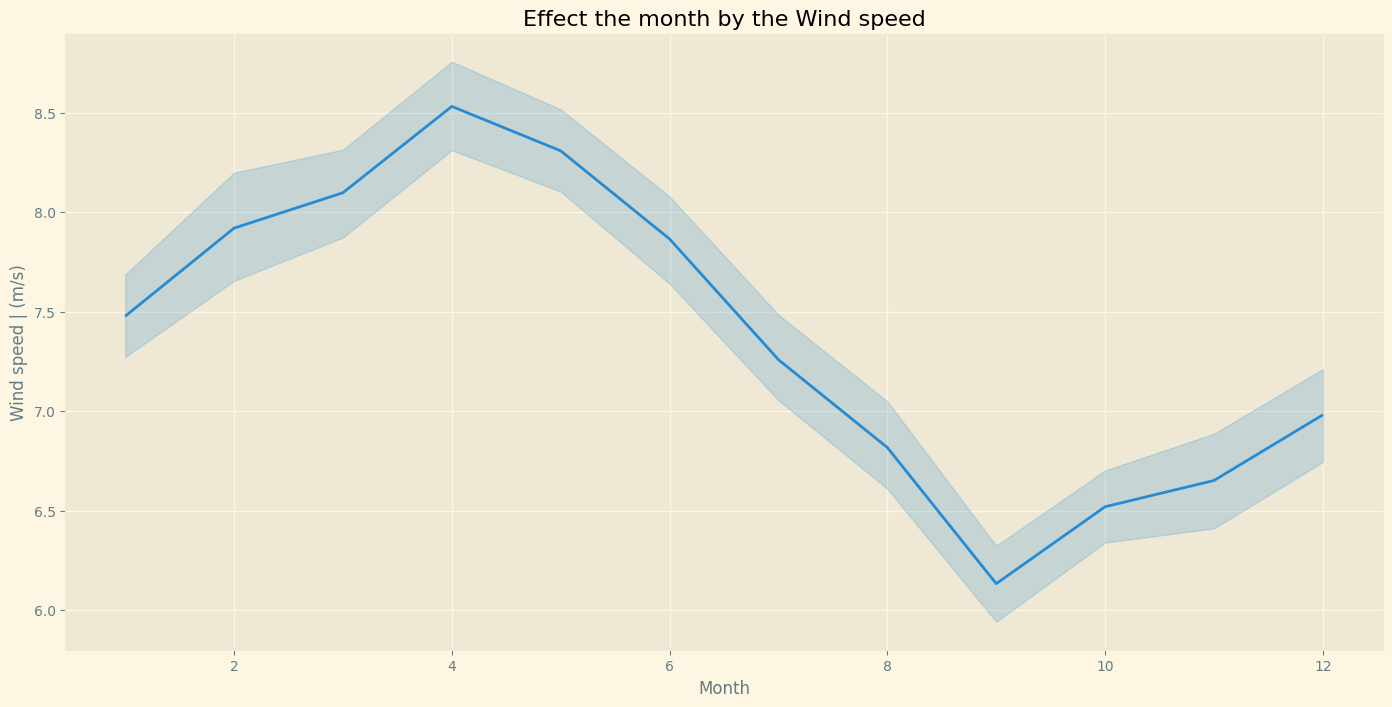

In [ ]:
# the graph show effect the month by the Wind speed

plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="Month",y="Wind speed | (m/s)")
plt.title("Effect the month by the Wind speed")
plt.show()

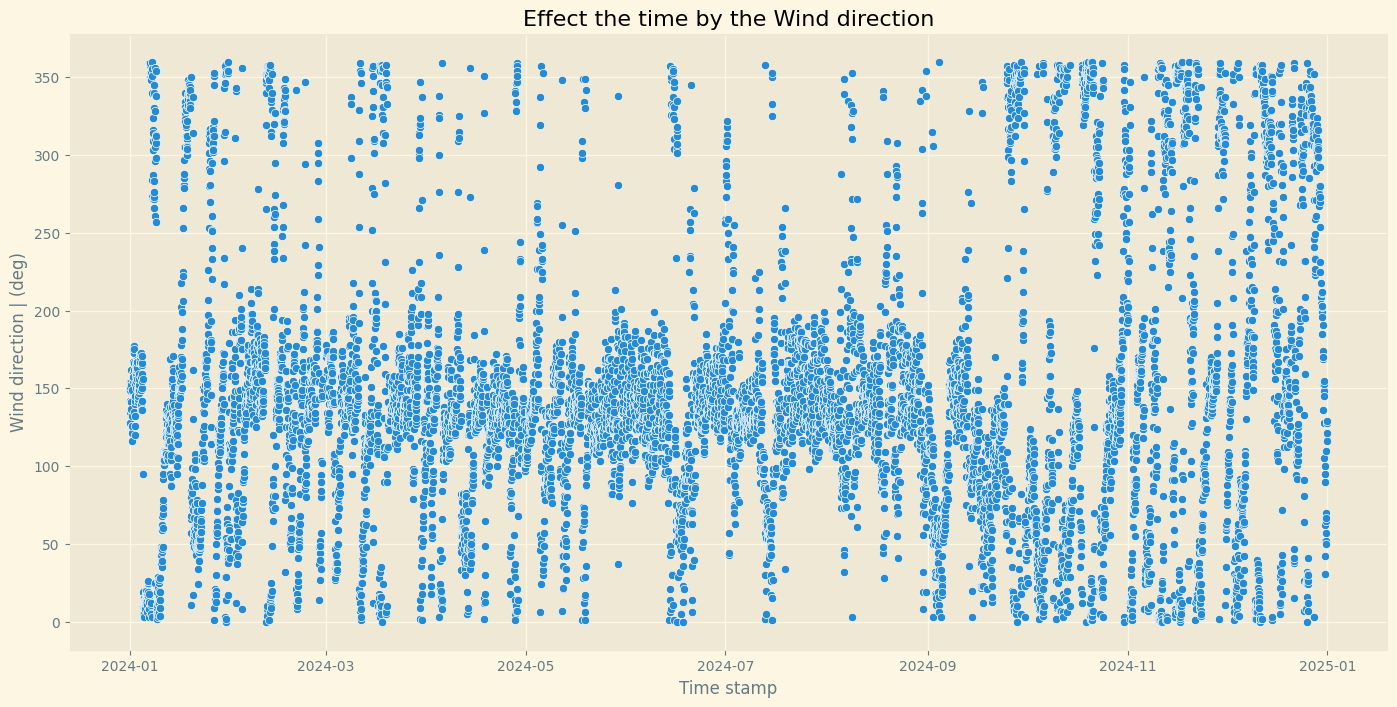

In [ ]:
# the graph show effect the time by Wind direction

plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="Time stamp",y="Wind direction | (deg)",)
plt.title("Effect the time by the Wind direction")
plt.show()

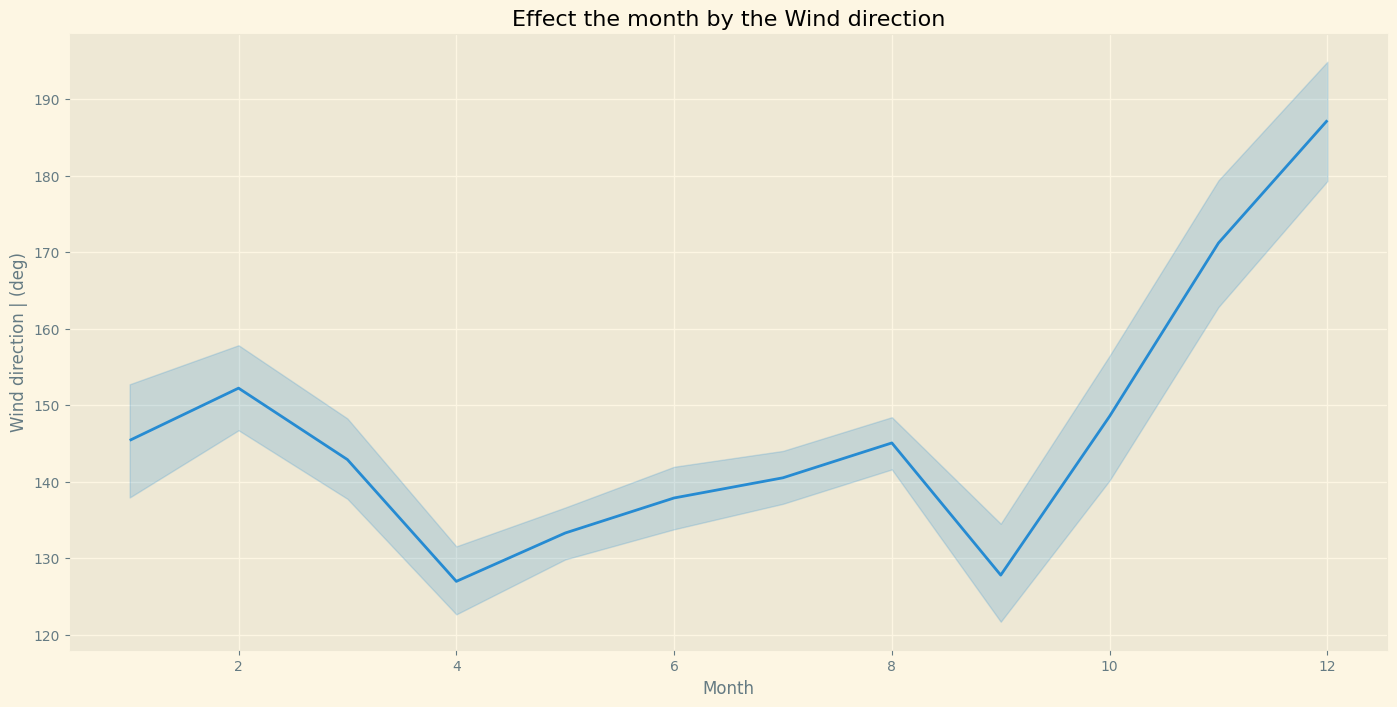

In [ ]:
# the graph show effect the month by the Wind direction

plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="Month",y="Wind direction | (deg)",)
plt.title("Effect the month by the Wind direction")
plt.show()

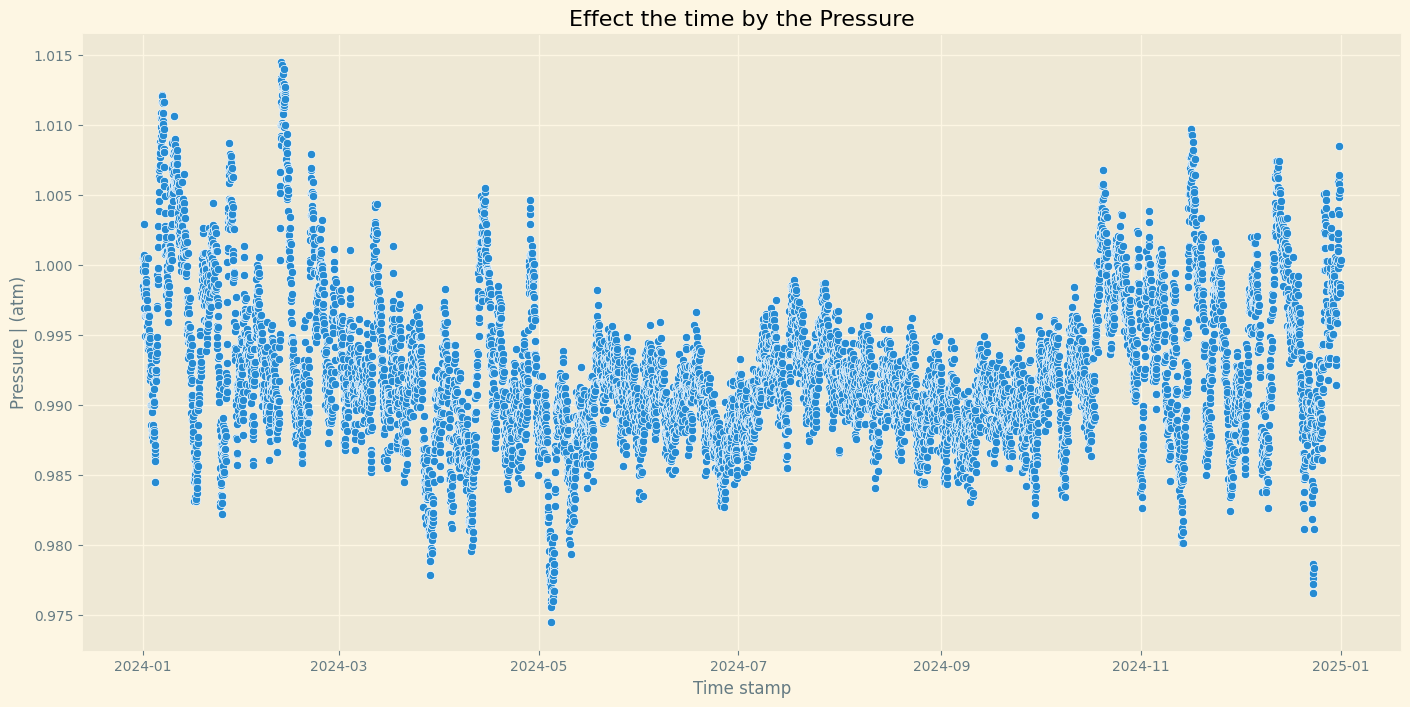

In [ ]:
# the graph show effect the time by the Pressure

plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="Time stamp",y="Pressure | (atm)")
plt.title("Effect the time by the Pressure")
plt.show()

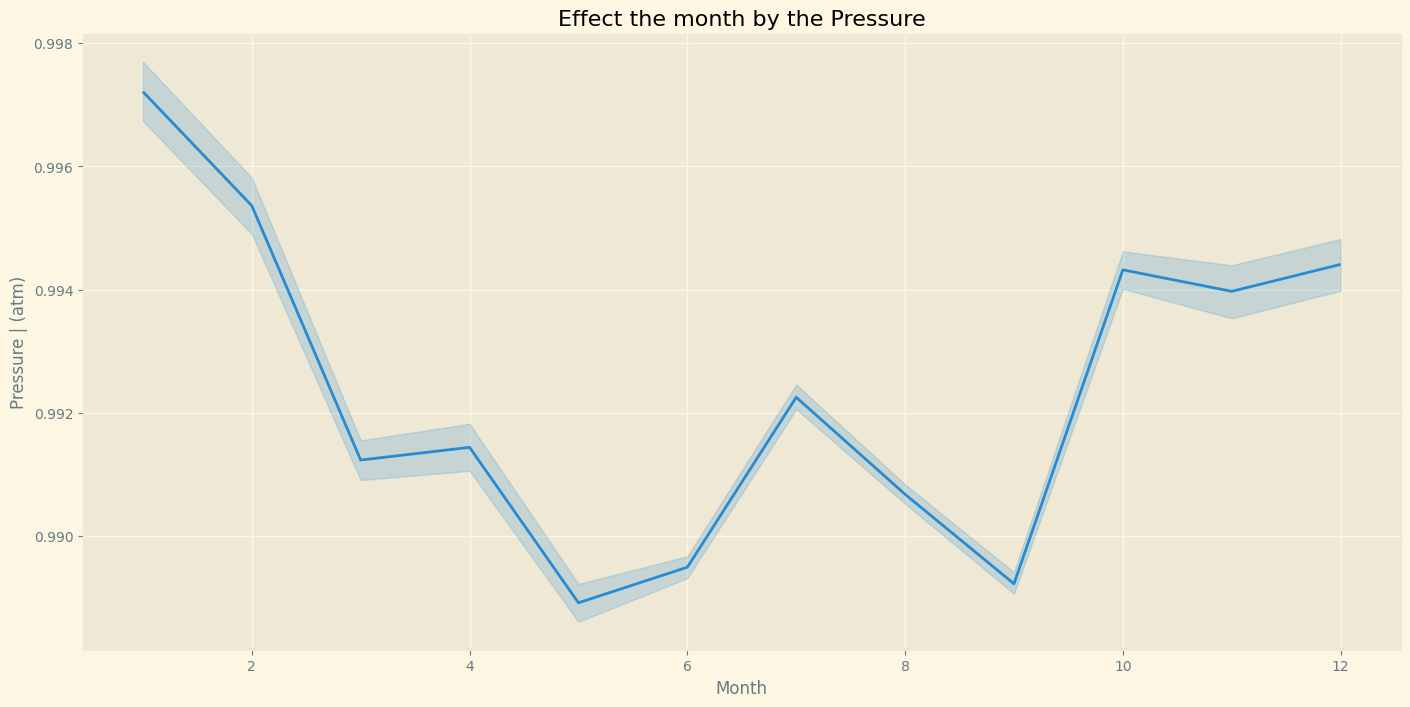

In [ ]:
# the graph show effect the month by the Pressure

plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="Month",y="Pressure | (atm)",)
plt.title("Effect the month by the Pressure")
plt.show()

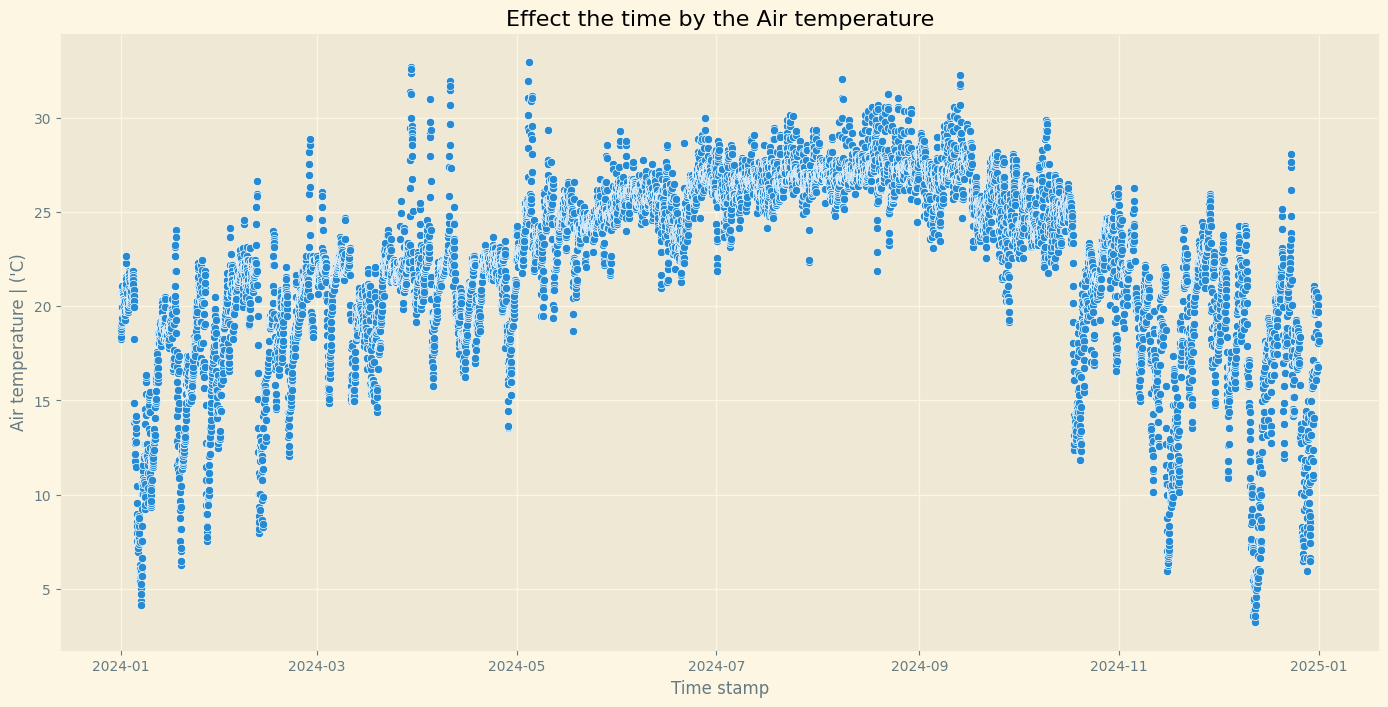

In [ ]:
# the graph show effect the time by the Air temperature

plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="Time stamp",y="Air temperature | ('C)")
plt.title("Effect the time by the Air temperature")
plt.show()

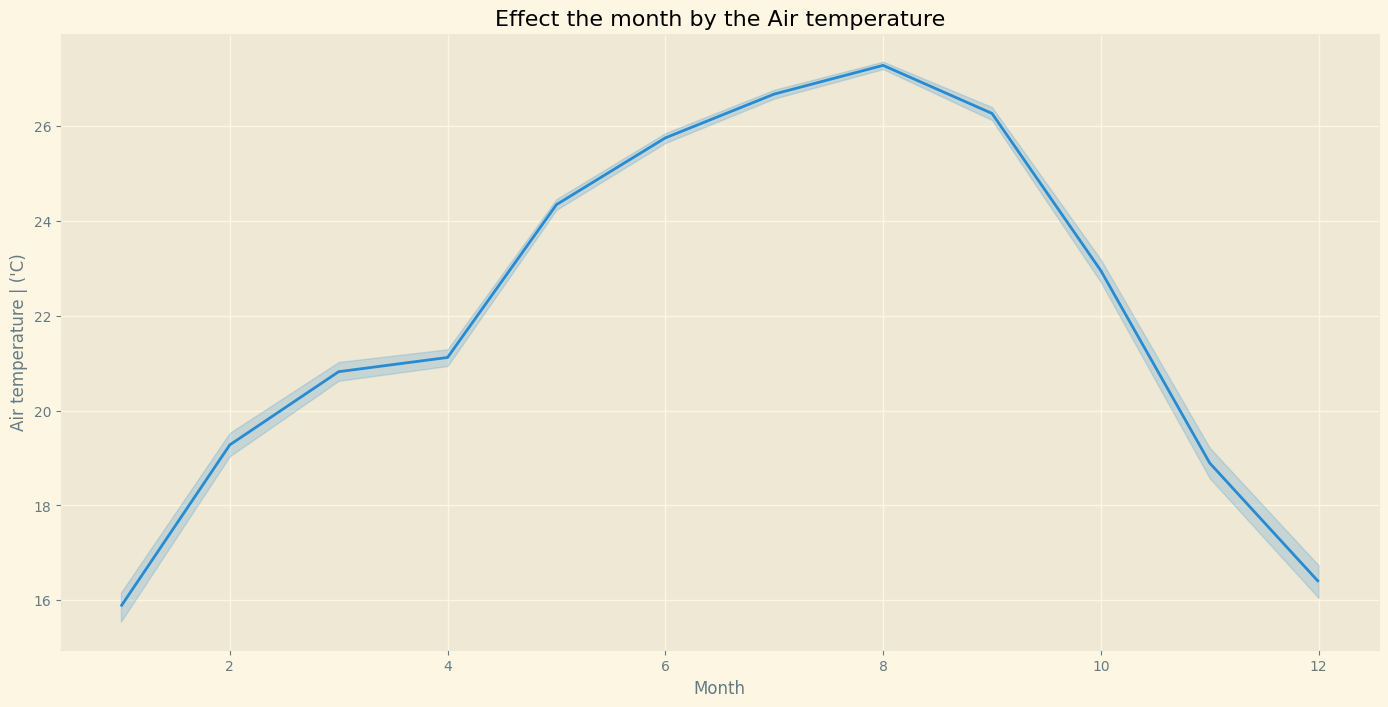

In [ ]:
# the graph show effect the month by the Air temperature

plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="Month",y="Air temperature | ('C)",)
plt.title("Effect the month by the Air temperature")
plt.show()

Analysis Results
After made some visualizations I have some results:
System power generated
Through the year- we see not different System power generated - all the months the same.
The high average System power generated in April and the less in September.
Wind speed
Wind speed the same all months.
The high average Wind speed in April and the less in September.
Wind direction
The high average Wind direction in December and the less in April and August.
The Pressure
The Pressure stable between May to october and anther months it is an fluctuate.
The high average Pressure in January and the less from April to September.
The temperature
Sure the summer season that high temperature - From May th October.
2- Building a Machine Learning Model - Regression 🙄🙄🙄
Prediction - System power generated | (kW)


In [ ]:
#Importing the basic librarires for building model


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error ,mean_squared_error, median_absolute_error,confusion_matrix,accuracy_score,r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler ,PolynomialFeatures,minmax_scale,MaxAbsScaler ,LabelEncoder,MinMaxScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.svm import SVR
from xgboost import XGBRegressor

In [ ]:
df.set_index("Time stamp",inplace=True)

In [ ]:
df.head()

,System power generated | (kW),Wind speed | (m/s),Wind direction | (deg),Pressure | (atm),Air temperature | ('C),Month
Time stamp,,,,,,
2024-01-01 00:00:00,1766.64,9.926,128,1.000480,18.263,1
2024-01-01 01:00:00,1433.83,9.273,135,0.999790,18.363,1
2024-01-01 02:00:00,1167.23,8.660,142,0.999592,18.663,1
2024-01-01 03:00:00,1524.59,9.461,148,0.998309,18.763,1
2024-01-01 04:00:00,1384.28,9.184,150,0.998507,18.963,1


In [ ]:
#Defined X value and y value , and split the data train
X = df.drop(columns="System power generated | (kW)")
y = df["System power generated | (kW)"]    # y = system power generated

# split the data train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("X Train : ", X_train.shape)
print("X Test  : ", X_test.shape)
print("Y Train : ", y_train.shape)
print("Y Test  : ", y_test.shape)

X Train :  (6132, 5)
X Test  :  (2628, 5)
Y Train :  (6132,)
Y Test  :  (2628,)


In [ ]:
#Defined object from library Regression

LR = LinearRegression()
DTR = DecisionTreeRegressor()
RFR = RandomForestRegressor()
KNR = KNeighborsRegressor()
MLP = MLPRegressor()
XGB = XGBRegressor()
SVR = SVR()

In [ ]:
# make for loop for Regression

li = [LR,DTR,RFR,KNR,KNR,XGB,SVR]
d = {}
for i in li:
    i.fit(X_train,y_train)
    ypred = i.predict(X_test)
    print(i,":",r2_score(y_test,ypred)*100)
    d.update({str(i):i.score(X_test,y_test)*100})

LinearRegression() : 91.15180354603353
DecisionTreeRegressor() : 99.98663840055971
RandomForestRegressor() : 99.99596759282531
KNeighborsRegressor() : 93.4547729570837
KNeighborsRegressor() : 93.4547729570837
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 99.99452462693648
SVR() : -6.1902339346

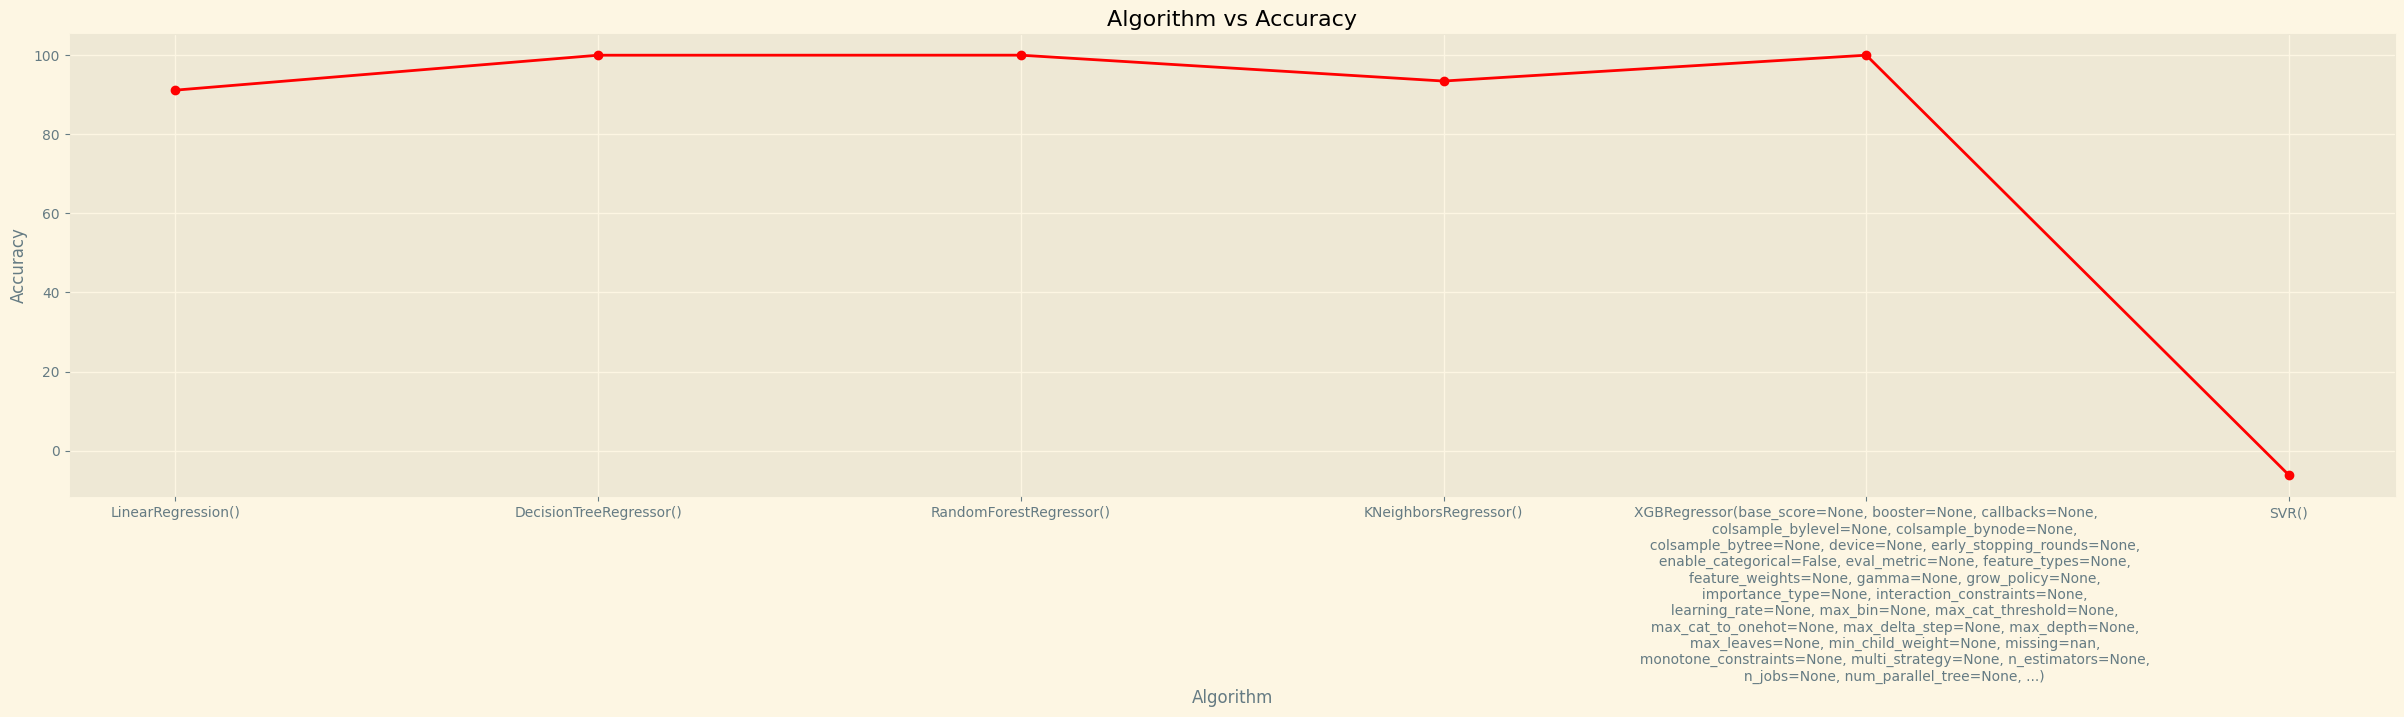

In [ ]:
# make graph about Accuracy

plt.figure(figsize=(30, 6))
plt.title("Algorithm vs Accuracy")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.plot(d.keys(),d.values(),marker='o',color='red')
plt.show()

Model Selection Results 😃😃😃
LinearRegression --> 91.1
DecisionTreeRegressor --> 99.9
RandomForestRegressor --> 99.9
KNeighborsRegressor -->93.4
KNeighborsRegressor -->93.4
XGBRegressor -->99.9
Notes 😃😃😃😃
Thank for reading my analysis and my regression. 😃😃😃😃

If you any questions or advice me please write in the comment . ❤️❤️❤️❤️

If anyone has a model with a higher percentage, please tell me 🤝🤝🤝

In [ ]:
print("\n----- Enter Your Own Data for Prediction -----")

# 1) Өөрийн өгөгдөл оруулах
wind_speed = float(input("Wind speed (m/s): "))
wind_direction = float(input("Wind direction (deg): "))
pressure = float(input("Pressure (atm): "))
air_temp = float(input("Air temperature (°C): "))
month = int(input("Month number (1-12): "))

# 2) Time stamp шаардлагатай тул түр placeholder хэрэглэнэ
now = pd.Timestamp.now()

# 3) DataFrame болгож X-ийн баганатай тааруулна
user_df = pd.DataFrame({
    "Wind speed | (m/s)": [wind_speed],
    "Wind direction | (deg)": [wind_direction],
    "Pressure | (atm)": [pressure],
    "Air temperature | ('C)": [air_temp],
    "Month": [month]
})

# 4) Аль модель хамгийн өндөр оноо авсныг сонгоно
best_model_name = max(d, key=d.get)
print(f"\nBest Model: {best_model_name}")

# model-ийг string → object болгож авна
for m in [LR, DTR, RFR, KNR, MLP, XGB, SVR]:
    if str(m) == best_model_name:
        best_model = m
        break

# 5) Таамаглал хийх
prediction = best_model.predict(user_df)[0]

print(f"\nPredicted System Power (kW): {prediction:.3f}")
print("-----------------------------------------------\n")


----- Enter Your Own Data for Prediction -----
Wind speed (m/s): 7.965
Wind direction (deg): 300
Pressure (atm): 1.027
Air temperature (°C): -19
Month number (1-12): 12

Best Model: RandomForestRegressor()

Predicted System Power (kW): 929.818
-----------------------------------------------



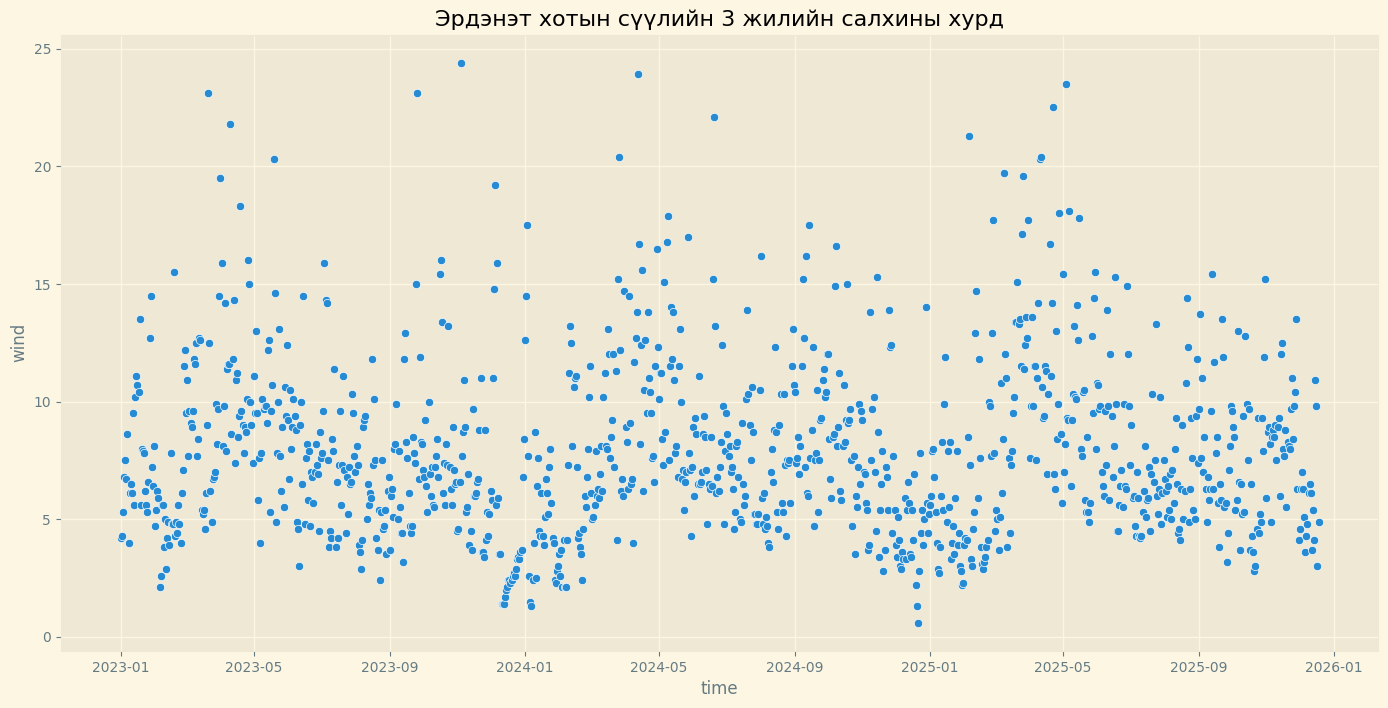

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("Solarize_Light2")  #using style ggplot

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import datetime as dt
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
df = pd.read_excel("/content/ET_data.xlsx")
plt.figure(figsize=(17,8))
sns.scatterplot(data=df,x="time",y="wind",)
plt.title("Эрдэнэт хотын сүүлийн 3 жилийн салхины хурд")
plt.show()

In [ ]:
wind_mean = df["wind"].mean()
print("Салхины дундаж хурд :", wind_mean)

Салхины дундаж хурд : 7.964912280701754


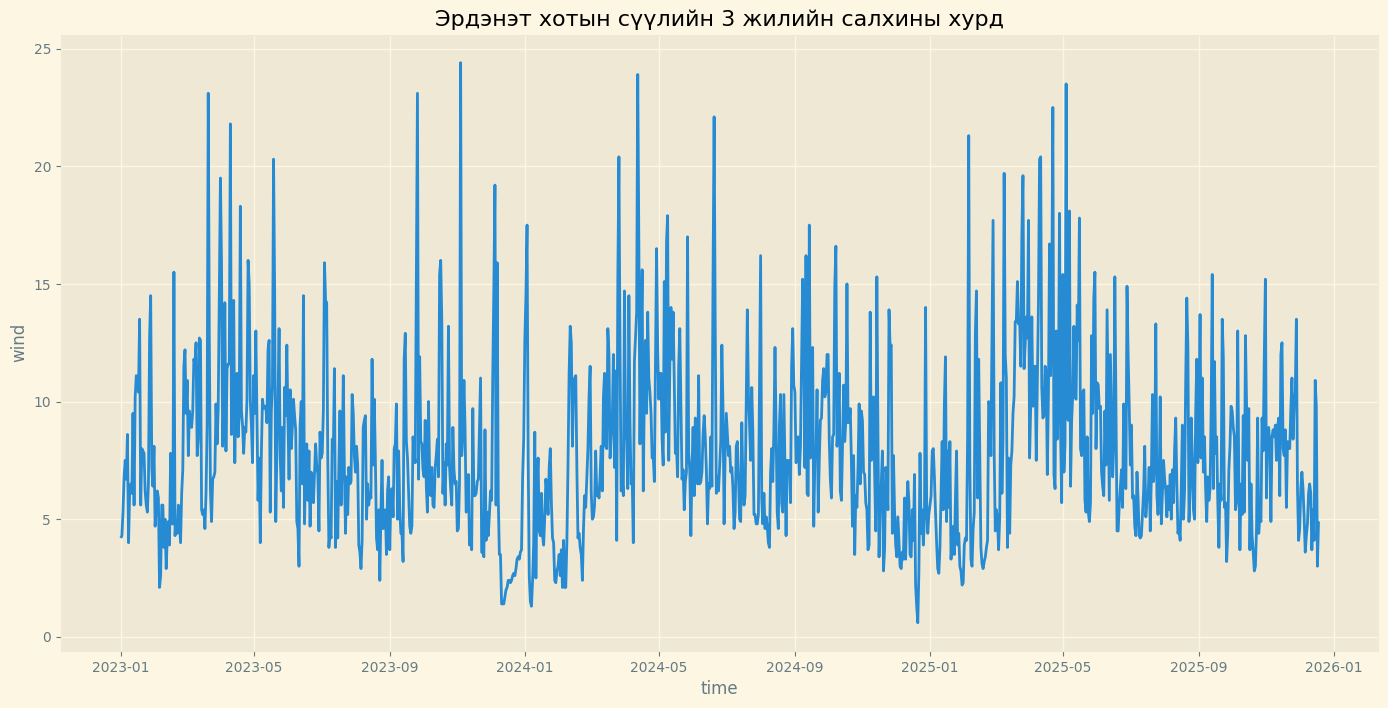

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("Solarize_Light2")  #using style ggplot

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import datetime as dt
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
df = pd.read_excel("/content/ET_data.xlsx")
plt.figure(figsize=(17,8))
sns.lineplot(data=df,x="time",y="wind",)
plt.title("Эрдэнэт хотын сүүлийн 3 жилийн салхины хурд")
plt.show()

In [ ]:
# =========================================
# Only Wind speed Excel-ээс авч таамаглах
# Бусад feature-үүдийг mean утгаар авна
# (ERROR FIXED)
# =========================================

import pandas as pd

# 1) Wind speed Excel-ээс унших
wind_df = pd.read_excel("/content/ET_data.xlsx")

# 2) Хамгийн сайн моделио сонгох
best_model_name = max(d, key=d.get)
print(f"Best Model: {best_model_name}")

for m in [LR, DTR, RFR, KNR, MLP, XGB, SVR]:
    if str(m) == best_model_name:
        best_model = m
        break

# 3) X_train-ийн mean утгаар 1 мөр DataFrame үүсгэх
X_base = X_train.mean().to_frame().T

# 4) Wind speed-ийн мөрийн тоогоор давтах
X_pred = pd.concat([X_base] * len(wind_df), ignore_index=True)

# 5) Wind speed баганыг Excel-ээс авсан утгаар солих
X_pred["Wind speed | (m/s)"] = wind_df["wind"].values

# 6) Таамаглал хийх
wind_df["Predicted System Power (kW)"] = best_model.predict(X_pred)

# 7) Үр дүн шалгах
print(wind_df.head())

# 8) Excel файлд хадгалах
wind_df.to_excel("/content/Predicted_System_Power.xlsx", index=False)

print("\nPrediction completed successfully.")


Best Model: RandomForestRegressor()
        time  wind  Predicted System Power (kW)
0 2023-01-01   4.2                    99.886443
1 2023-01-02   4.3                   113.044460
2 2023-01-03   5.3                   245.606130
3 2023-01-04   6.8                   549.400320
4 2023-01-05   7.5                   741.102770

Prediction completed successfully.


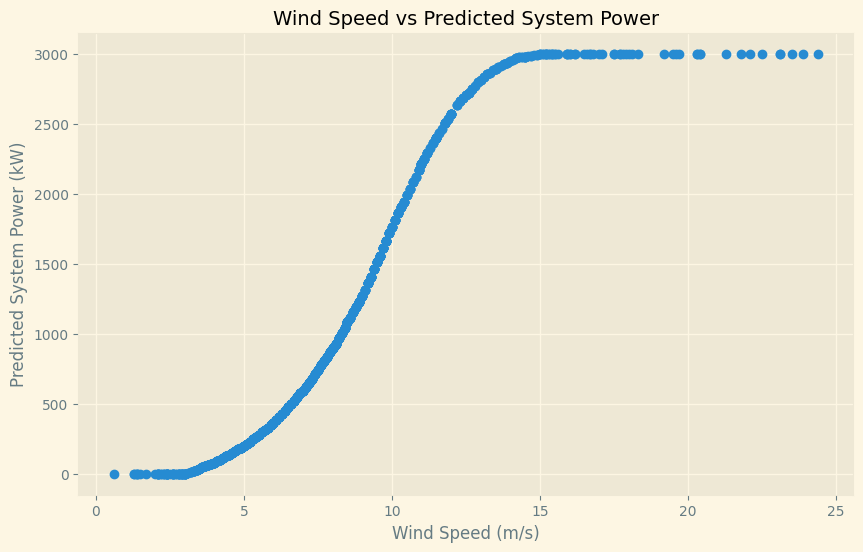

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Үүссэн Excel файл унших
df_plot = pd.read_excel("/content/Predicted_System_Power.xlsx")

# 2) Цэгэн график байгуулах
plt.figure(figsize=(10, 6))

plt.scatter(
    df_plot["wind"],
    df_plot["Predicted System Power (kW)"]
)

plt.title("Wind Speed vs Predicted System Power", fontsize=14)
plt.xlabel("Wind Speed (m/s)", fontsize=12)
plt.ylabel("Predicted System Power (kW)", fontsize=12)

plt.grid(True)
plt.show()


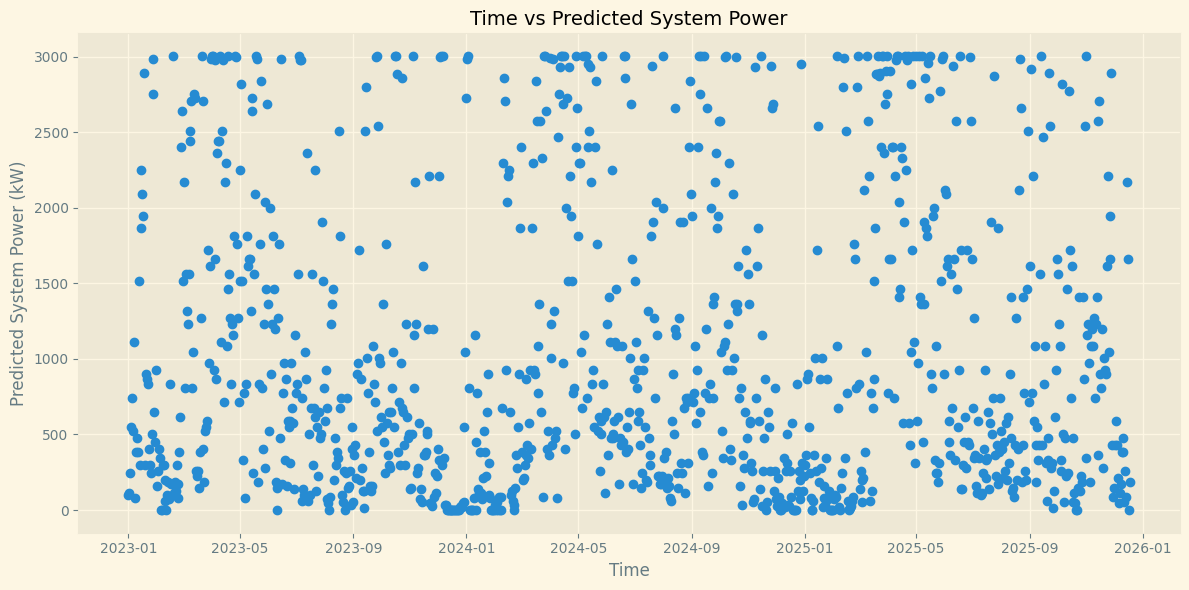

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Excel файл унших
df_plot = pd.read_excel("/content/Predicted_System_Power.xlsx")

# 2) time баганыг datetime төрөлд хөрвүүлэх
df_plot["time"] = pd.to_datetime(df_plot["time"])

# 3) time-ээр эрэмбэлэх (чухал)
df_plot = df_plot.sort_values(by="time")

# 4) График байгуулах
plt.figure(figsize=(12, 6))

plt.scatter(
    df_plot["time"],
    df_plot["Predicted System Power (kW)"],
    linestyle="-"
)

plt.title("Time vs Predicted System Power", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Predicted System Power (kW)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()
